In [19]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully
Pandas version: 2.3.3
NumPy version: 2.4.6


In [12]:
# Load the Dataset
df = pd.read_csv('data/raw/ai4i2020.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset loaded successfully!
Shape: (10000, 14)

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [13]:
# Dataset Info & Missing Values
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution (Machine Failure) ===")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.2f}%")


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

In [14]:
# Statistical Summary
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


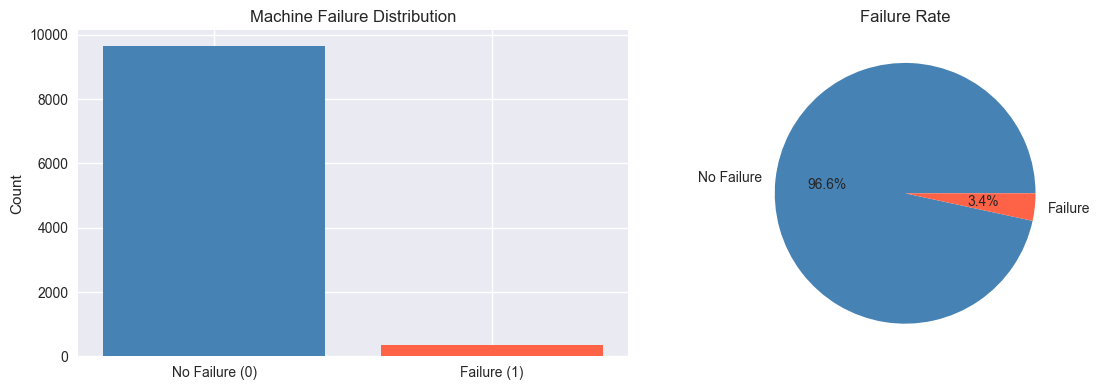

Plot saved


In [18]:
# Class Imbalance Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['No Failure (0)', 'Failure (1)'], 
            df['Machine failure'].value_counts().values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Machine Failure Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(df['Machine failure'].value_counts().values,
            labels=['No Failure', 'Failure'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%')
axes[1].set_title('Failure Rate')

plt.tight_layout()
plt.savefig('data/class_distribution.png', dpi=150)
plt.show()
print("Plot saved")

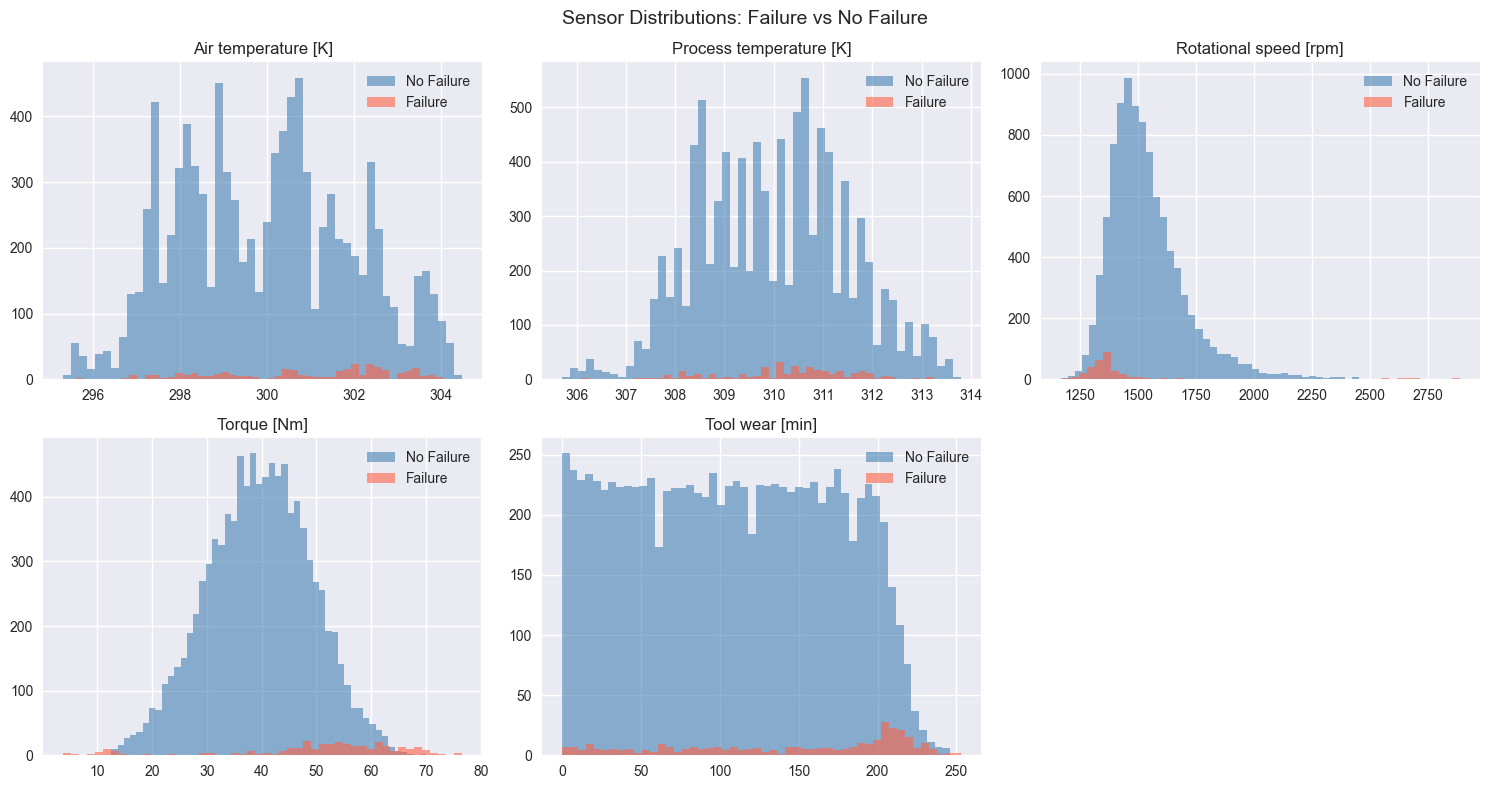

Plot saved


In [17]:
# Cell 6 - Sensor Feature Distributions
features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[df['Machine failure']==0][feature], 
                 bins=50, alpha=0.6, color='steelblue', label='No Failure')
    axes[i].hist(df[df['Machine failure']==1][feature], 
                 bins=50, alpha=0.6, color='tomato', label='Failure')
    axes[i].set_title(feature)
    axes[i].legend()

axes[5].axis('off')  # hide empty subplot
plt.suptitle('Sensor Distributions: Failure vs No Failure', fontsize=14)
plt.tight_layout()
plt.savefig('data/sensor_distributions.png', dpi=150)
plt.show()
print("Plot saved")

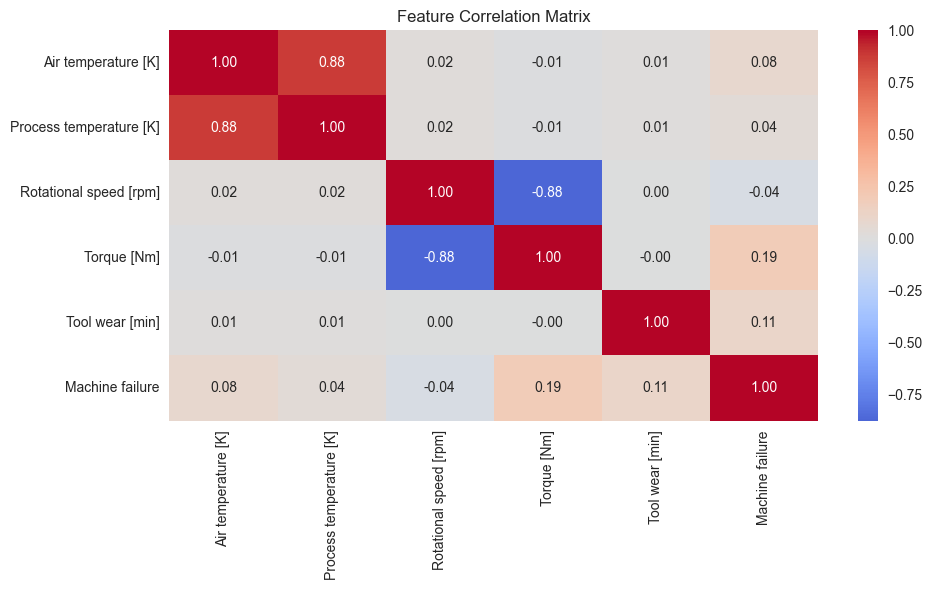

In [20]:
# Correlation heatmap
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 
                'Tool wear [min]', 'Machine failure']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('data/correlation_matrix.png', dpi=150)
plt.show()

In [21]:
# Preprocessing and Feature Engineering
from sklearn.preprocessing import LabelEncoder

# Drop identifier columns not useful for modeling
df_model = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# Encode 'Type' column (L, M, H → 0, 1, 2)
le = LabelEncoder()
df_model['Type'] = le.fit_transform(df_model['Type'])

# Engineer new feature: Torque x Tool wear interaction
df_model['Torque_x_Toolwear'] = df_model['Torque [Nm]'] * df_model['Tool wear [min]']

# Engineer temperature difference
df_model['Temp_difference'] = df_model['Process temperature [K]'] - df_model['Air temperature [K]']

print("Final feature set:")
print(df_model.columns.tolist())
print(f"\nShape: {df_model.shape}")
df_model.head()

Final feature set:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Torque_x_Toolwear', 'Temp_difference']

Shape: (10000, 9)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_x_Toolwear,Temp_difference
0,2,298.1,308.6,1551,42.8,0,0,0.0,10.5
1,1,298.2,308.7,1408,46.3,3,0,138.9,10.5
2,1,298.1,308.5,1498,49.4,5,0,247.0,10.4
3,1,298.2,308.6,1433,39.5,7,0,276.5,10.4
4,1,298.2,308.7,1408,40.0,9,0,360.0,10.5


In [22]:
# Train/Test Split and Save Processed Data
from sklearn.model_selection import train_test_split

# Define features and target
X = df_model.drop(columns=['Machine failure'])
y = df_model['Machine failure']

# Split: 80% train, 20% test — stratified to preserve failure ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nFailure rate in train: {y_train.mean()*100:.2f}%")
print(f"Failure rate in test:  {y_test.mean()*100:.2f}%")

# Save processed data
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print("\nProcessed data saved to data/processed/")

Training set: (8000, 8)
Test set:     (2000, 8)

Failure rate in train: 3.39%
Failure rate in test:  3.40%

Processed data saved to data/processed/
